In [1]:
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
# from scipy.integrate import quad, trapz

# Quantum Circuits

In [2]:
alphas = np.loadtxt("data/dimer-model-qc/alpha.csv", delimiter=",")

L = len(alphas)

### Dimer Model

In [3]:
# Extract phases from results in other scripts

spins_4 = np.loadtxt("data/dimer-model-qc/4-spins.csv", delimiter=",")
spins_6 = np.loadtxt("data/dimer-model-qc/6-spins.csv", delimiter=",")
spins_8 = np.loadtxt("data/dimer-model-qc/8-spins.csv", delimiter=",")

berry_phases = [spins_4, spins_6, spins_8]

In [4]:
def errors(berry_phases):
    n_systems = len(berry_phases)
    l = len(berry_phases[0])

    exact_phases = np.zeros(l)
    exact_phases[0 : int(l / 2) + 1] = np.pi

    square_err = np.zeros((n_systems, l))
    abs_err = np.zeros((n_systems, l))

    for i in range(n_systems):
        for j in range(l):
            abs_err[i][j] = np.abs(exact_phases[j] - berry_phases[i][j])
            square_err[i][j] = (exact_phases[j] - berry_phases[i][j]) ** 2

        # Save to CSV
        np.savetxt(
            f"data/dimer-model-qc/{(i*2)+4}-spins-sq-error.csv",
            square_err[i],
            delimiter=",",
        )
        np.savetxt(
            f"data/dimer-model-qc/{(i*2)+4}-spins-abs-error.csv",
            abs_err[i],
            delimiter=",",
        )

        # FOr vis purposes
        square_err[i][10] = None

    return square_err, abs_err

In [5]:
sq_err, abs_err = errors(berry_phases)

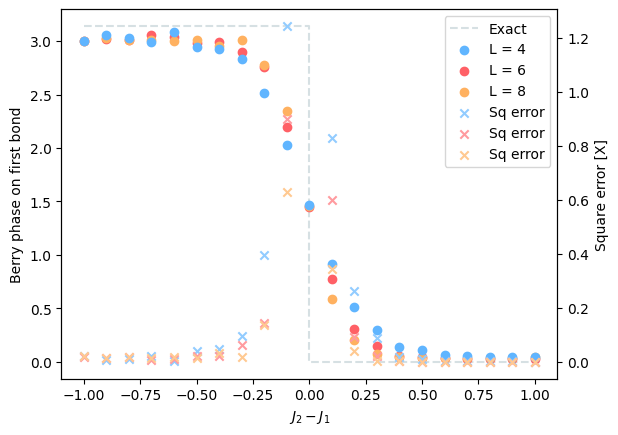

In [6]:
rgb = (0.839, 0.878, 0.89)

c4 = (0.376, 0.71, 1.0)
c4e = (0.573, 0.80, 1.0)

c6 = (1.0, 0.376, 0.4)
c6e = (1.0, 0.608, 0.624)

c8 = (1.0, 0.694, 0.376)
c8e = (1.0, 0.788, 0.569)

# Create the first plot
fig, ax1 = plt.subplots()

l = len(alphas)
exact_phases = np.zeros(l)
exact_phases[0 : int(l / 2) + 1] = np.pi

diff = alphas - 1


p0 = ax1.step(diff, exact_phases, color=rgb, linestyle="--", label="Exact", zorder=1)
p1 = ax1.scatter(diff, berry_phases[0], color=c4, label="L = 4", zorder=4)
p2 = ax1.scatter(diff, berry_phases[1], color=c6, label="L = 6", zorder=3)
p3 = ax1.scatter(diff, berry_phases[2], color=c8, label="L = 8", zorder=3)

# Create the second y-axis and plot on it
ax2 = ax1.twinx()
p4 = ax2.scatter(diff, sq_err[0], color=c4e, marker="x", zorder=1, label="Sq error")
p5 = ax2.scatter(diff, sq_err[1], color=c6e, marker="x", zorder=1, label="Sq error")
p6 = ax2.scatter(diff, sq_err[2], color=c8e, marker="x", zorder=1, label="Sq error")

# Labels
ax1.set_xlabel("$J_2 - J_1$")
ax1.set_ylabel("Berry phase on first bond")
ax1.tick_params(axis="y")

ax2.set_ylabel("Square error [X]")
ax2.tick_params(axis="y")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them together
handles = handles1 + handles2
labels = labels1 + labels2

# Add the combined legend
ax1.legend(handles, labels, loc="best")

# Display the plot
plt.show()

### Tetra model

In [7]:
J1 = np.loadtxt("data/tetra-model-qc/n-100/j1.csv", delimiter=" ")
J2 = np.loadtxt("data/tetra-model-qc/n-100/j2.csv", delimiter=" ")

diff = J2 - J1
L = len(diff)

In [8]:
# Extract phases from results in other scripts

import pandas as pd

spins_4 = np.loadtxt("data/tetra-model-qc/n-100/berry.csv", delimiter=",")
spins_6 = np.loadtxt("data/tetra-model-qc/n-200/berry.csv", delimiter=",")
spins_8 = np.loadtxt("data/tetra-model-qc/n-300/berry.csv", delimiter=",")

berry_phases = [spins_4, spins_6, spins_8]

In [9]:
def errors(berry_phases):
    n_systems = len(berry_phases)
    l = len(berry_phases[0])

    exact_phases = np.zeros(l)
    exact_phases[0 : int(l / 2) + 1] = np.pi

    square_err = np.zeros((n_systems, l))
    abs_err = np.zeros((n_systems, l))

    for i in range(n_systems):
        for j in range(l):
            abs_err[i][j] = np.abs(exact_phases[j] - berry_phases[i][j])
            square_err[i][j] = (exact_phases[j] - berry_phases[i][j]) ** 2

        # Save to CSV
        np.savetxt(
            f"data/tetra-model-qc/n-{(i+1)*100}/sq-error.csv",
            square_err[i],
            delimiter=",",
        )
        np.savetxt(
            f"data/tetra-model-qc/n-{(i+1)*100}/abs-error.csv",
            abs_err[i],
            delimiter=",",
        )

        # FOr vis purposes
        square_err[i][10] = None
        square_err[i][11] = None

    return square_err, abs_err, exact_phases

In [10]:
sq_err, abs_err, exact_phases = errors(berry_phases)

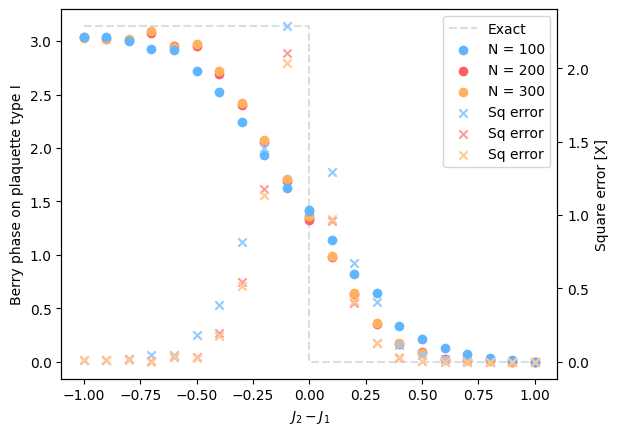

In [11]:
rgb = (0.839, 0.878, 0.89)

c4 = (0.376, 0.71, 1.0)
c4e = (0.573, 0.80, 1.0)

c6 = (1.0, 0.376, 0.4)
c6e = (1.0, 0.608, 0.624)

c8 = (1.0, 0.694, 0.376)
c8e = (1.0, 0.788, 0.569)

# Create the first plot
fig, ax1 = plt.subplots()

p0 = ax1.step(diff, exact_phases, color=rgb, linestyle="--", label="Exact", zorder=1)
p1 = ax1.scatter(diff, berry_phases[0], color=c4, label="N = 100", zorder=4)
p2 = ax1.scatter(diff, berry_phases[1], color=c6, label="N = 200", zorder=3)
p3 = ax1.scatter(diff, berry_phases[2], color=c8, label="N = 300", zorder=3)

# Create the second y-axis and plot on it
ax2 = ax1.twinx()
p4 = ax2.scatter(diff, sq_err[0], color=c4e, marker="x", zorder=1, label="Sq error")
p5 = ax2.scatter(diff, sq_err[1], color=c6e, marker="x", zorder=1, label="Sq error")
p6 = ax2.scatter(diff, sq_err[2], color=c8e, marker="x", zorder=1, label="Sq error")

# Labels
ax1.set_xlabel("$J_2 - J_1$")
ax1.set_ylabel("Berry phase on plaquette type I")
ax1.tick_params(axis="y")

ax2.set_ylabel("Square error [X]")
ax2.tick_params(axis="y")

# Legend
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine them together
handles = handles1 + handles2
labels = labels1 + labels2

# Add the combined legend
ax1.legend(handles, labels, loc="best")

# Display the plot
plt.show()

Gate and depths

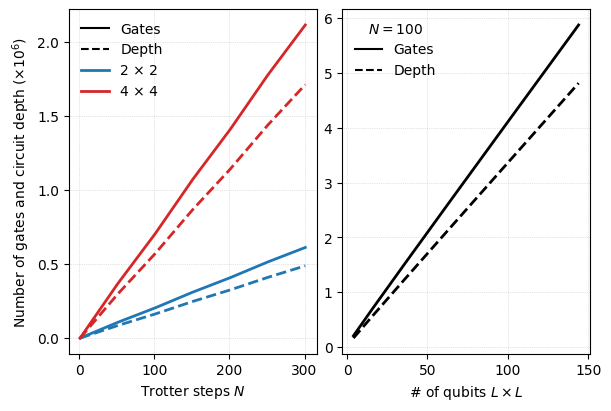

In [12]:
import numpy as np
from matplotlib.lines import Line2D
from matplotlib import pyplot as plt

trotter_steps = np.loadtxt("data/tetra-model-qc/trotter-counts/Ns.csv", delimiter=",")
gates_2x2 = np.loadtxt("data/tetra-model-qc/trotter-counts/2x2-gates.csv", delimiter=",")
depths_2x2 = np.loadtxt("data/tetra-model-qc/trotter-counts/2x2-depths.csv", delimiter=",")
gates_4x4 = np.loadtxt("data/tetra-model-qc/trotter-counts/4x4-gates.csv", delimiter=",")
depths_4x4 = np.loadtxt("data/tetra-model-qc/trotter-counts/4x4-depths.csv", delimiter=",")

fig, [ax, ax2] = plt.subplots(ncols=2, figsize=(6, 4))

# 2x2
ax.plot(trotter_steps, gates_2x2 / 1e6,
        color="tab:blue", linestyle="-", linewidth=2)
ax.plot(trotter_steps, depths_2x2 / 1e6,
        color="tab:blue", linestyle="--", linewidth=2)

# 4x4
ax.plot(trotter_steps, gates_4x4 / 1e6,
        color="tab:red", linestyle="-", linewidth=2)
ax.plot(trotter_steps, depths_4x4 / 1e6,
        color="tab:red", linestyle="--", linewidth=2)

ax.set_xlabel("Trotter steps $N$")
ax.set_ylabel("Number of gates and circuit depth ($\\times 10^6$)")

legend_elements = [
    Line2D([0], [0], color="black", linestyle="-", label="Gates"),
    Line2D([0], [0], color="black", linestyle="--", label="Depth"),
    Line2D([0], [0], color="tab:blue", lw=2, label="2 × 2"),
    Line2D([0], [0], color="tab:red", lw=2, label="4 × 4"),
]

ax.legend(handles=legend_elements, frameon=False)

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)

system_steps = np.loadtxt("data/tetra-model-qc/system-size-counts/sizes.csv", delimiter=",")
gates = np.loadtxt("data/tetra-model-qc/system-size-counts/gates.csv", delimiter=",")
depths = np.loadtxt("data/tetra-model-qc/system-size-counts/depths.csv", delimiter=",")

# 2x2
ax2.plot(system_steps ** 2, gates / 1e6,
        color="black", linestyle="-", linewidth=2)
ax2.plot(system_steps ** 2, depths / 1e6,
        color="black", linestyle="--", linewidth=2)


ax2.set_xlabel(r"# of qubits $L \times L$")

legend_elements = [
    Line2D([0], [0], color="black", linestyle="-", label="Gates"),
    Line2D([0], [0], color="black", linestyle="--", label="Depth"),
]

ax2.legend(handles=legend_elements, frameon=False, title=r"$N=100$")

ax2.grid(True, linestyle=":", linewidth=0.5, alpha=0.7)

fig.tight_layout(pad=0.3)